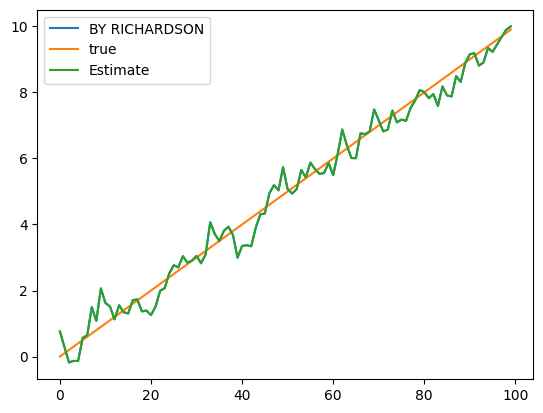

In [1]:
import numpy as np
import matplotlib.pyplot as plt
class KalmanFi1ter:
    def __init__(self, F, H, Q, R, x0, P0):
        self.F=F
        self.H=H
        self.Q=Q
        self.R=R
        self.x=x0
        self.P=P0
    def predict (self):
        self.x=np.dot(self.F,self.x)
        self.P=np.dot(np.dot(self. F,self. P),self.F.T)+self.Q
    def update(self,z):
        y=z-np.dot(self.H,self.x)
        s=np.dot(np.dot(self.H,self.P),self.H.T)+self.R
        K=np.dot(np.dot(self.P,self.H.T),np.linalg.inv(s))
        self.x=self.x+np.dot(K,y)
        self.P=np.dot(np.eye(self.F.shape[0])-np.dot(K,self.H),self.P)
dt=0.1
F=np.array([[1,dt],[0,1]])
H=np.array([[1,0]])
Q=np.diag([0.1,0.1])
R=np.array([[1]])
x0=np.array([0,0])
P0=np.diag([1,1])
kf=KalmanFi1ter(F,H,Q,R,x0,P0)
truestates=[]
measurements=[]
for i in range(100):
    truestates.append([i*dt,1])
    measurements.append(i*dt+np.random.normal(scale=1))
est_states=[]
for z in measurements:
    kf.predict()
    kf.update(np.array([z]))
    est_states.append(kf.x)
    
plt.plot([s[0] for s in est_states],label="BY RICHARDSON")
plt.plot([s[0] for s in truestates],label="true")
plt.plot([s[0] for s in est_states],label="Estimate")
plt.legend()
plt.show()